In [7]:
import matplotlib.pyplot as plt
import matplotlib
import numpy
import os

from rascil.processing_components import plot_uvcoverage

from radioimaging.visibility import ingest, bda, residual
from radioimaging import images
from radioimaging.util import util

plt.set_loglevel("critical")
cmap='turbo'
matplotlib.rcParams['figure.figsize'] = [5, 5]
from rascil.processing_components import create_visibility_from_ms

In [2]:
dataset_name = "../data8/SGRC_MID_averaged.ms"
output_name = "../data8/SGRC_MID_averaged"
ells = [3, 10, 35, 70]
use_hardcoded_ells = False
delta = 1

[vis], _ = ingest.create_visibility_from_ms(dataset_name, use_weight_spec=True)
npix = 512
cell_size = 8.75517e-07
print(vis.vis.shape)

(1, 8514449, 1, 1)


/home/sunwang/.local/lib/python3.10/site-packages/ska_sdp_datamodels/visibility/vis_model.py:190: FutureWarning: the `pandas.MultiIndex` object(s) passed as 'baselines' coordinate(s) or data variable(s) will no longer be implicitly promoted and wrapped into multiple indexed coordinates in the future (i.e., one coordinate for each multi-index level + one dimension coordinate). If you want to keep this behavior, you need to first wrap it explicitly using `mindex_coords = xarray.Coordinates.from_pandas_multiindex(mindex_obj, 'dim')` and pass it as coordinates, e.g., `xarray.Dataset(coords=mindex_coords)`, `dataset.assign_coords(mindex_coords)` or `dataarray.assign_coords(mindex_coords)`.
  return cls(datavars, coords=coords, attrs=attrs)


There is no flagged visibility. Skip plotting flagged.
/home/sunwang/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


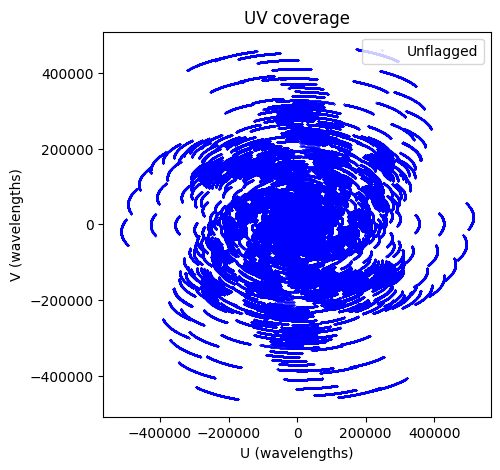

In [3]:
plot_uvcoverage([vis])

In [4]:
matplotlib.rcParams['figure.figsize'] = [10, 5]

dirty, psf = residual.dirty_psf_from_visibilities(vis,cell_size,npix=npix,weighting="uniform", override_cellsize=False)
fdirty = numpy.abs(numpy.fft.fftshift(numpy.fft.fft2(numpy.fft.ifftshift(dirty.pixels.data[0,0,:,:]))))
fpsf = numpy.abs(numpy.fft.fftshift(numpy.fft.fft2(numpy.fft.ifftshift(psf.pixels.data[0,0,:,:]))))

Model image plate scale (arcsec) is 1.805883e-01


Ells: [19, 35, 56, 87]


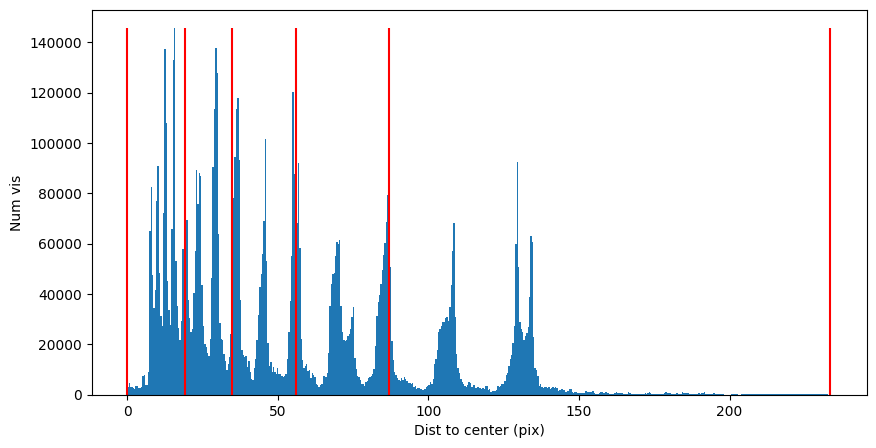

In [5]:
sep_pix = bda.generate_telescope_histogram(vis, show_partitions=True, num_partitions=5,\
                                     show_pixel_hist=True, n_pixels=512, pixel_size=cell_size)

if not use_hardcoded_ells:
    ells = [int(numpy.round(x)) for x in sep_pix[1:-1]]
    print("Ells: " + str(ells))

In [8]:
centers_str = ""
for ell in ells:
    centers_str += str(ell) + " "
    
split_exec = "python split_datasets.py --idataset_name " + dataset_name + " --num_pix " + str(npix) + \
    " --pix_rad " + str(cell_size) + " --halfwidth " + str(delta) + " --centers " + centers_str + \
    "--odataset_name " + output_name

os.system(split_exec)

2025-08-26 08:05:55	INFO	SubMS::parseColumnNames()	Using DATA column.
2025-08-26 08:06:11	INFO	SubMS::makeSelection()	1901491 out of 8514449 rows are going to be considered due to the selection criteria.
2025-08-26 08:06:19	INFO	SubMS::parseColumnNames()	Using DATA column.
2025-08-26 08:06:35	INFO	SubMS::makeSelection()	2052996 out of 8514449 rows are going to be considered due to the selection criteria.
2025-08-26 08:06:44	INFO	SubMS::parseColumnNames()	Using DATA column.
2025-08-26 08:06:57	INFO	SubMS::makeSelection()	1851974 out of 8514449 rows are going to be considered due to the selection criteria.
2025-08-26 08:07:06	INFO	SubMS::parseColumnNames()	Using DATA column.
2025-08-26 08:07:19	INFO	SubMS::makeSelection()	2044646 out of 8514449 rows are going to be considered due to the selection criteria.
2025-08-26 08:07:27	INFO	SubMS::parseColumnNames()	Using DATA column.
2025-08-26 08:07:39	INFO	SubMS::makeSelection()	1747925 out of 8514449 rows are going to be considered due to the 

0

/home/sunwang/.local/lib/python3.10/site-packages/ska_sdp_datamodels/visibility/vis_model.py:190: FutureWarning: the `pandas.MultiIndex` object(s) passed as 'baselines' coordinate(s) or data variable(s) will no longer be implicitly promoted and wrapped into multiple indexed coordinates in the future (i.e., one coordinate for each multi-index level + one dimension coordinate). If you want to keep this behavior, you need to first wrap it explicitly using `mindex_coords = xarray.Coordinates.from_pandas_multiindex(mindex_obj, 'dim')` and pass it as coordinates, e.g., `xarray.Dataset(coords=mindex_coords)`, `dataset.assign_coords(mindex_coords)` or `dataarray.assign_coords(mindex_coords)`.
  return cls(datavars, coords=coords, attrs=attrs)
There is no flagged visibility. Skip plotting flagged.
/home/sunwang/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_i

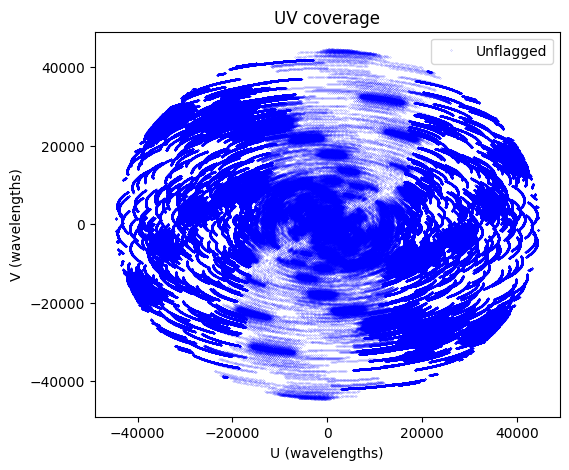

Model image plate scale (arcsec) is 1.805883e-01


/home/sunwang/.local/lib/python3.10/site-packages/ska_sdp_datamodels/visibility/vis_model.py:190: FutureWarning: the `pandas.MultiIndex` object(s) passed as 'baselines' coordinate(s) or data variable(s) will no longer be implicitly promoted and wrapped into multiple indexed coordinates in the future (i.e., one coordinate for each multi-index level + one dimension coordinate). If you want to keep this behavior, you need to first wrap it explicitly using `mindex_coords = xarray.Coordinates.from_pandas_multiindex(mindex_obj, 'dim')` and pass it as coordinates, e.g., `xarray.Dataset(coords=mindex_coords)`, `dataset.assign_coords(mindex_coords)` or `dataarray.assign_coords(mindex_coords)`.
  return cls(datavars, coords=coords, attrs=attrs)
There is no flagged visibility. Skip plotting flagged.
/home/sunwang/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_i

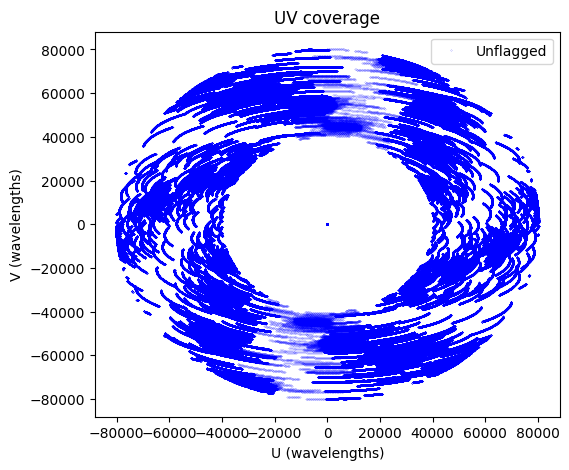

Model image plate scale (arcsec) is 1.805883e-01


/home/sunwang/.local/lib/python3.10/site-packages/ska_sdp_datamodels/visibility/vis_model.py:190: FutureWarning: the `pandas.MultiIndex` object(s) passed as 'baselines' coordinate(s) or data variable(s) will no longer be implicitly promoted and wrapped into multiple indexed coordinates in the future (i.e., one coordinate for each multi-index level + one dimension coordinate). If you want to keep this behavior, you need to first wrap it explicitly using `mindex_coords = xarray.Coordinates.from_pandas_multiindex(mindex_obj, 'dim')` and pass it as coordinates, e.g., `xarray.Dataset(coords=mindex_coords)`, `dataset.assign_coords(mindex_coords)` or `dataarray.assign_coords(mindex_coords)`.
  return cls(datavars, coords=coords, attrs=attrs)
There is no flagged visibility. Skip plotting flagged.
/home/sunwang/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_i

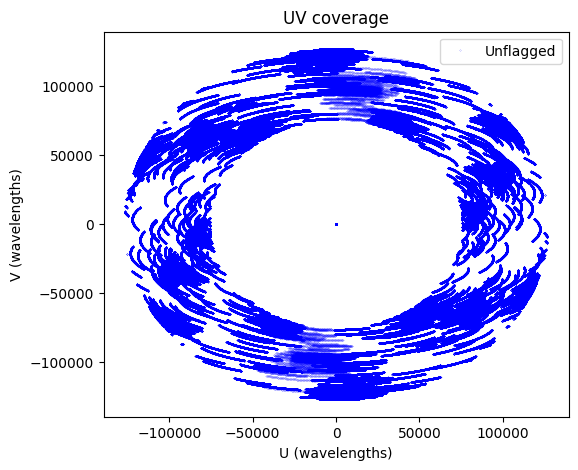

Model image plate scale (arcsec) is 1.805883e-01


/home/sunwang/.local/lib/python3.10/site-packages/ska_sdp_datamodels/visibility/vis_model.py:190: FutureWarning: the `pandas.MultiIndex` object(s) passed as 'baselines' coordinate(s) or data variable(s) will no longer be implicitly promoted and wrapped into multiple indexed coordinates in the future (i.e., one coordinate for each multi-index level + one dimension coordinate). If you want to keep this behavior, you need to first wrap it explicitly using `mindex_coords = xarray.Coordinates.from_pandas_multiindex(mindex_obj, 'dim')` and pass it as coordinates, e.g., `xarray.Dataset(coords=mindex_coords)`, `dataset.assign_coords(mindex_coords)` or `dataarray.assign_coords(mindex_coords)`.
  return cls(datavars, coords=coords, attrs=attrs)
There is no flagged visibility. Skip plotting flagged.
/home/sunwang/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_i

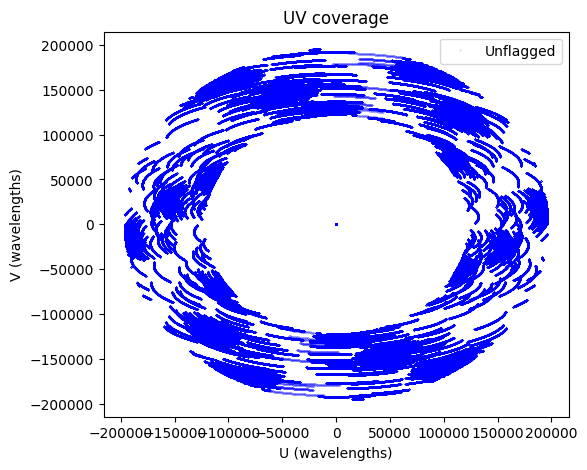

Model image plate scale (arcsec) is 1.805883e-01


/home/sunwang/.local/lib/python3.10/site-packages/ska_sdp_datamodels/visibility/vis_model.py:190: FutureWarning: the `pandas.MultiIndex` object(s) passed as 'baselines' coordinate(s) or data variable(s) will no longer be implicitly promoted and wrapped into multiple indexed coordinates in the future (i.e., one coordinate for each multi-index level + one dimension coordinate). If you want to keep this behavior, you need to first wrap it explicitly using `mindex_coords = xarray.Coordinates.from_pandas_multiindex(mindex_obj, 'dim')` and pass it as coordinates, e.g., `xarray.Dataset(coords=mindex_coords)`, `dataset.assign_coords(mindex_coords)` or `dataarray.assign_coords(mindex_coords)`.
  return cls(datavars, coords=coords, attrs=attrs)
There is no flagged visibility. Skip plotting flagged.
/home/sunwang/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_i

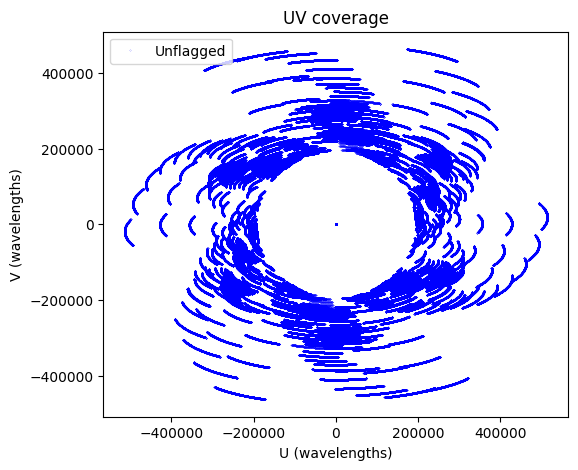

Model image plate scale (arcsec) is 1.805883e-01


In [11]:
matplotlib.rcParams['figure.figsize'] = [6, 5]
import gc

from rascil.processing_components import create_visibility_from_ms

psfs = []
dirties = []
fdirties = []

for ell in ells:
    gc.collect()
    curr_ms_file = output_name + str(ell) + ".ms"
    [curr_vis] = create_visibility_from_ms(curr_ms_file)
    
    if vis.vis.size < 5e7:
        plot_uvcoverage([curr_vis])
    
    curr_dirty, curr_psf = residual.dirty_psf_from_visibilities(curr_vis,cell_size,npix=npix,weighting="uniform")
    curr_fdirty = numpy.abs(numpy.fft.fftshift(numpy.fft.fft2(numpy.fft.ifftshift(curr_dirty.pixels.data[0,0,:,:]))))
    
    psfs.append(curr_psf)
    dirties.append(curr_dirty)
    fdirties.append(curr_fdirty)

gc.collect()
    
curr_ms_file = output_name + str(ells[-1]) + "plus.ms"
[curr_vis] = create_visibility_from_ms(curr_ms_file)

if curr_vis.vis.size < 5e7:
    plot_uvcoverage([curr_vis])

curr_dirty, curr_psf = residual.dirty_psf_from_visibilities(curr_vis,cell_size,npix=npix,weighting="uniform")
curr_fdirty = numpy.abs(numpy.fft.fftshift(numpy.fft.fft2(numpy.fft.ifftshift(curr_dirty.pixels.data[0,0,:,:]))))

psfs.append(curr_psf)
dirties.append(curr_dirty)
fdirties.append(curr_fdirty)

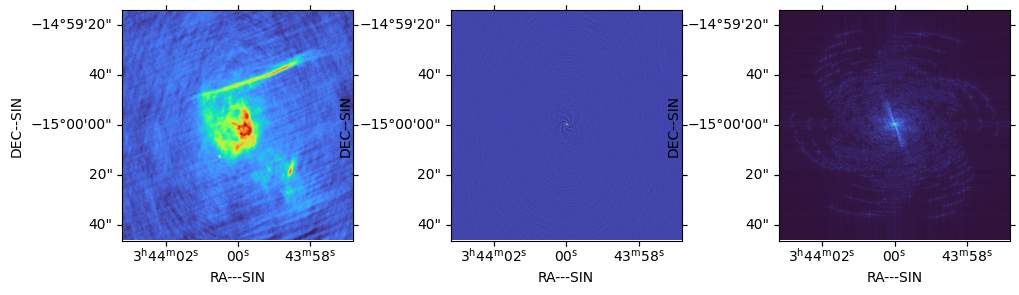

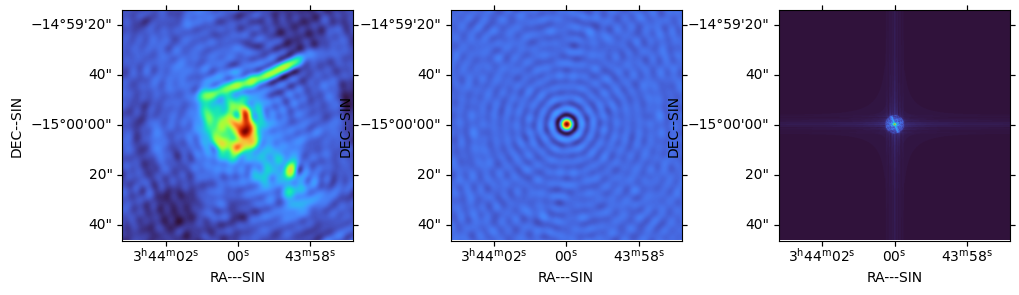

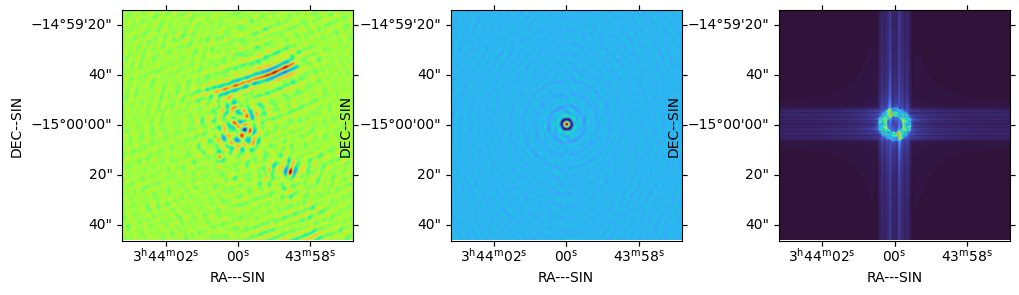

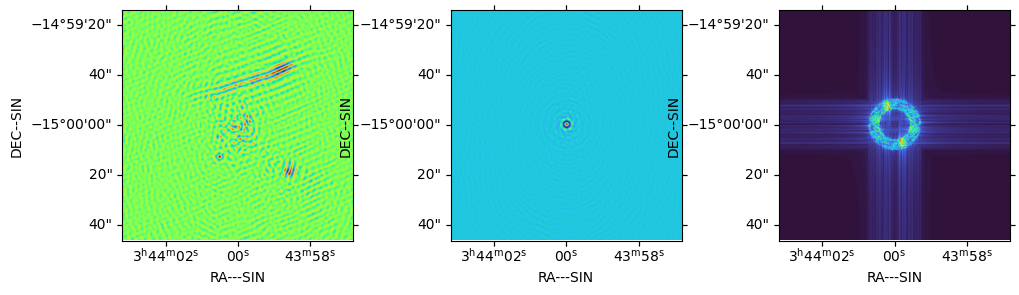

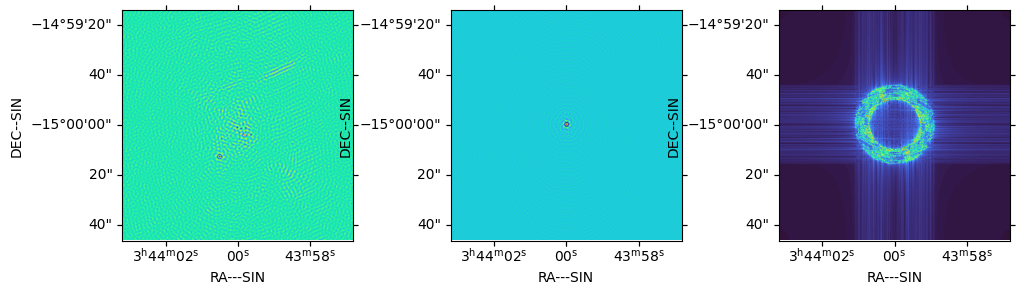

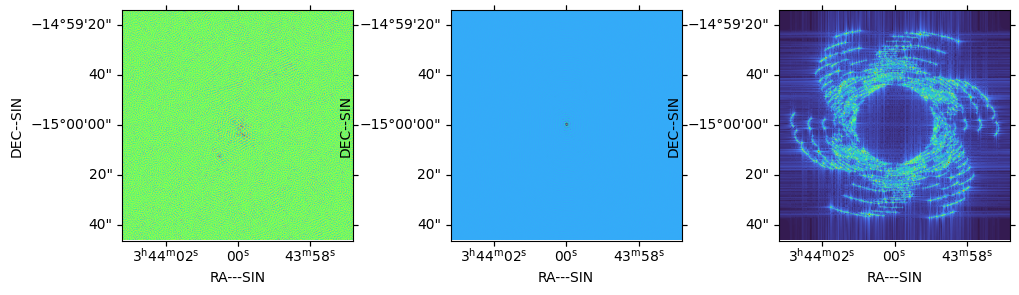

In [12]:
num_datasets = len(ells) + 1

fig = plt.figure(figsize=(12,3))
ax=fig.add_subplot(1,3,1,projection=dirty.image_acc.wcs.sub([1, 2]))
ax.imshow(dirty.pixels.data[0,0,:,:],origin='lower',cmap=cmap)
ax.set_xlabel(dirty.image_acc.wcs.wcs.ctype[0])
ax.set_ylabel(dirty.image_acc.wcs.wcs.ctype[1])

ax=fig.add_subplot(1,3,2,projection=psf.image_acc.wcs.sub([1, 2]))
ax.imshow(psf.pixels.data[0,0,:,:],origin='lower',cmap=cmap)
ax.set_xlabel(psf.image_acc.wcs.wcs.ctype[0])
ax.set_ylabel(psf.image_acc.wcs.wcs.ctype[1])

ax=fig.add_subplot(1,3,3,projection=dirty.image_acc.wcs.sub([1, 2]))
ax.imshow(numpy.sqrt(fdirty),origin='lower',cmap=cmap)
ax.set_xlabel(dirty.image_acc.wcs.wcs.ctype[0])
ax.set_ylabel(dirty.image_acc.wcs.wcs.ctype[1])

#display all partitions
for i, curr_dirty in enumerate(dirties):
    fig = plt.figure(figsize=(12,3))
    ax=fig.add_subplot(1,3,1,projection=dirties[i].image_acc.wcs.sub([1, 2]))
    ax.imshow(dirties[i].pixels.data[0,0,:,:],origin='lower',cmap=cmap)
    ax.set_xlabel(dirties[i].image_acc.wcs.wcs.ctype[0])
    ax.set_ylabel(dirties[i].image_acc.wcs.wcs.ctype[1])

    ax=fig.add_subplot(1,3,2,projection=psfs[i].image_acc.wcs.sub([1, 2]))
    ax.imshow(psfs[i].pixels.data[0,0,:,:],origin='lower',cmap=cmap)
    ax.set_xlabel(psfs[i].image_acc.wcs.wcs.ctype[0])
    ax.set_ylabel(psfs[i].image_acc.wcs.wcs.ctype[1])

    ax=fig.add_subplot(1,3,3,projection=dirties[i].image_acc.wcs.sub([1, 2]))
    ax.imshow(numpy.sqrt(fdirties[i]),origin='lower',cmap=cmap)
    ax.set_xlabel(dirties[i].image_acc.wcs.wcs.ctype[0])
    ax.set_ylabel(dirties[i].image_acc.wcs.wcs.ctype[1])


(-0.5, 1.1)

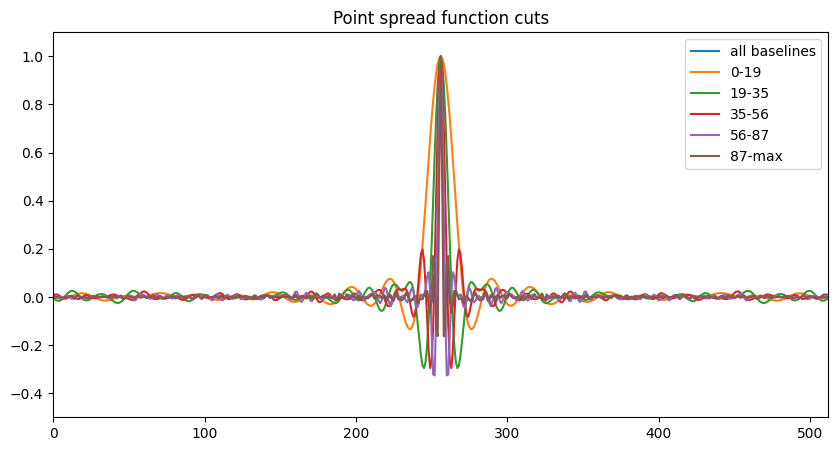

In [13]:
matplotlib.rcParams['figure.figsize'] = [10, 5]

size = 256

plt.plot(psf['pixels'].data[0,0,256,:],label='all baselines')
for i, curr_psf in enumerate(psfs):
    curr_range_low = 0 if i == 0 else ells[i - 1]
    curr_range_high = ells[i] if i < len(ells) else "max"
    range_label = str(curr_range_low) + "-" + str(curr_range_high)
    plt.plot(curr_psf['pixels'].data[0,0,256,:],label=range_label)
    
plt.legend()
plt.title('Point spread function cuts')
plt.xlim((256 - size, 256 + size)); plt.ylim((-0.5,1.1))